# GREGORY_COOPER_MSCS_634_ProjectDeliverable_3
**Dataset:** 2015 Flight Delays (flights.csv) — https://www.kaggle.com/datasets/usdot/flight-delays

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    accuracy_score, f1_score, classification_report
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


## SPart 1 – Data Loading and Preparation

We load a 100 000-row sample of flights.csv for speed, drop leaky delay-component columns (the same ones excluded in Deliverable 2), and engineer a binary target: **`DELAYED`** = 1 if arrival delay > 15 minutes, 0 otherwise. Features are drawn only from information available *before* the flight lands.

In [75]:
# Load data
SAMPLE_SIZE = 100_000
df_raw = pd.read_csv('flights.csv', nrows=SAMPLE_SIZE)
print(f'Loaded {len(df_raw):,} rows  |  {df_raw.shape[1]} columns')

Loaded 100,000 rows  |  31 columns


In [ ]:
#  Leaky / uninformative columns to drop 
DROP_COLS = [
    'DEPARTURE_DELAY',      # leakage: part of ARRIVAL_DELAY formula
    'AIR_SYSTEM_DELAY',     # leakage: post-flight breakdown
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
    'ARRIVAL_DELAY',        # raw target — replaced by binary DELAYED below
    'YEAR',                 # constant (all 2015)
    'DIVERTED',             # post-flight outcome
    'CANCELLED',            # post-flight outcome
    'CANCELLATION_REASON',  # only present for cancelled flights
    'TAIL_NUMBER',          # high-cardinality ID
    'FLIGHT_NUMBER',        # ID
    'WHEELS_OFF',           # post-departure time
    'WHEELS_ON',            # post-departure time
    'ELAPSED_TIME',         # only known after landing
    'AIR_TIME',             # only known after landing
    'ARRIVAL_TIME',         # only known after landing
]

df = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns])

# We need the raw ARRIVAL_DELAY just to build the label and, then drop it.
df['DELAYED'] = (df_raw['ARRIVAL_DELAY'].fillna(0) > 15).astype(int)

# Drop rows where key scheduling features are null
df = df.dropna(subset=['SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL',
                        'SCHEDULED_TIME', 'DISTANCE'])

# Encode categorical airline / airport codes as integers
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill any remaining numeric nulls with column median
df = df.fillna(df.median(numeric_only=True))

print(f'Working shape: {df.shape}')
print(f'Delay rate: {df["DELAYED"].mean()*100:.1f}%')
print('Feature columns:', [c for c in df.columns if c != 'DELAYED'])

Working shape: (100000, 14)
Delay rate: 33.6%
Feature columns: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'TAXI_IN', 'SCHEDULED_ARRIVAL']


In [ ]:
#  Train / test split 
FEATURES = [c for c in df.columns if c != 'DELAYED']
X = df[FEATURES]
y = df['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaled version for k-NN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 80,000  |  Test: 20,000


---
## Part 2 Classification Models

### Model 1: Decision Tree Classifier

Decision Trees split the feature space on the most informative features at each node. They are interpretable and handle mixed numeric/categorical data natively.

In [78]:
# Decision Tree (baseline, no tuning yet) 
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt    = dt.predict(X_test)
y_prob_dt    = dt.predict_proba(X_test)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print('=== Decision Tree ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'F1 Score : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['On-Time', 'Delayed']))

=== Decision Tree ===
Accuracy : 0.7550
F1 Score : 0.5706

              precision    recall  f1-score   support

     On-Time       0.77      0.89      0.83     13278
     Delayed       0.69      0.48      0.57      6722

    accuracy                           0.76     20000
   macro avg       0.73      0.69      0.70     20000
weighted avg       0.75      0.76      0.74     20000



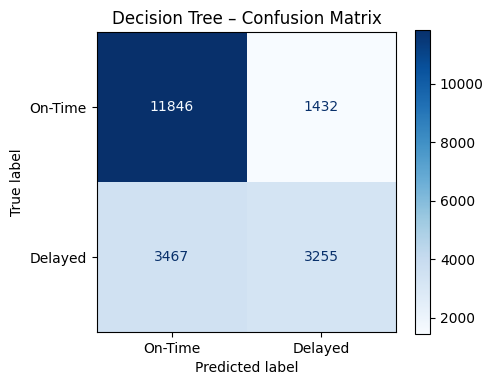

In [ ]:
# Confusion matrix  Decision Tree 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['On-Time', 'Delayed'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree – Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: k-Nearest Neighbors Classifier

In [ ]:
#  k-NN (k=11 as the starting baseline)
knn = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)

print('=== k-NN (k=11) ===')
print(f'Accuracy : {acc_knn:.4f}')
print(f'F1 Score : {f1_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['On-Time', 'Delayed']))

=== k-NN (k=11) ===
Accuracy : 0.7660
F1 Score : 0.5809

              precision    recall  f1-score   support

     On-Time       0.78      0.91      0.84     13278
     Delayed       0.73      0.48      0.58      6722

    accuracy                           0.77     20000
   macro avg       0.75      0.70      0.71     20000
weighted avg       0.76      0.77      0.75     20000



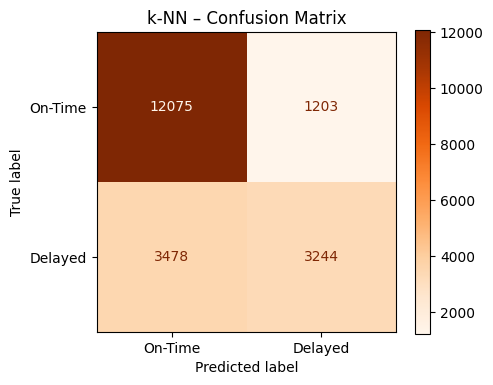

In [ ]:
# Confusion matrix  k-NN 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['On-Time', 'Delayed'],
    cmap='Oranges', ax=ax
)
ax.set_title('k-NN – Confusion Matrix')
plt.tight_layout()
plt.show()

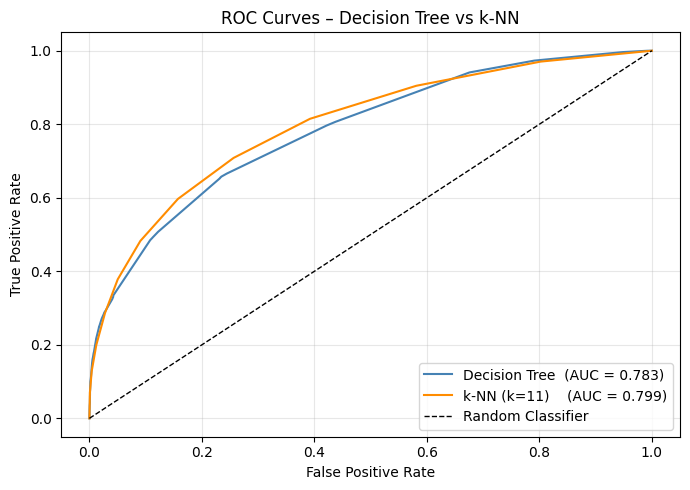

Decision Tree  AUC: 0.7835
k-NN           AUC: 0.7989


In [ ]:
# Side by side ROC curves 
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_dt  = auc(fpr_dt,  tpr_dt)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree  (AUC = {auc_dt:.3f})',  color='steelblue')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (k=11)    (AUC = {auc_knn:.3f})', color='darkorange')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Decision Tree vs k-NN')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Decision Tree  AUC: {auc_dt:.4f}')
print(f'k-NN           AUC: {auc_knn:.4f}')

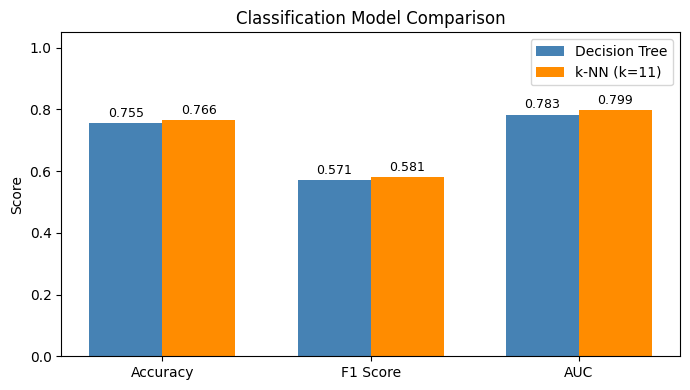

In [83]:
# Model comparison bar chart 
metrics = ['Accuracy', 'F1 Score', 'AUC']
dt_vals  = [acc_dt,  f1_dt,  auc_dt]
knn_vals = [acc_knn, f1_knn, auc_knn]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, dt_vals,  w, label='Decision Tree', color='steelblue')
ax.bar(x + w/2, knn_vals, w, label='k-NN (k=11)',   color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 3 – Hyperparameter Tuning (Decision Tree)

We use **GridSearchCV** with 5-fold cross-validation to tune the Decision Tree. 

In [84]:
#  GridSearchCV on Decision Tree
param_grid = {
    'max_depth':         [4, 6, 8, 10],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf':  [10, 20, 50],
    'criterion':         ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('Best parameters found:')
print(grid_search.best_params_)
print(f'Best CV F1: {grid_search.best_score_:.4f}')

Best parameters found:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 100}
Best CV F1: 0.7000


In [85]:
# Evaluate the tuned model 
dt_tuned = grid_search.best_estimator_

y_pred_tuned = dt_tuned.predict(X_test)
y_prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned  = f1_score(y_test, y_pred_tuned)
auc_tuned = auc(*roc_curve(y_test, y_prob_tuned)[:2])

print('=== Tuned Decision Tree ===')
print(f'Accuracy : {acc_tuned:.4f}  (baseline {acc_dt:.4f})')
print(f'F1 Score : {f1_tuned:.4f}  (baseline {f1_dt:.4f})')
print(f'AUC      : {auc_tuned:.4f}  (baseline {auc_dt:.4f})')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['On-Time', 'Delayed']))

=== Tuned Decision Tree ===
Accuracy : 0.8182  (baseline 0.7550)
F1 Score : 0.7015  (baseline 0.5706)
AUC      : 0.8714  (baseline 0.7835)

              precision    recall  f1-score   support

     On-Time       0.83      0.91      0.87     13278
     Delayed       0.78      0.64      0.70      6722

    accuracy                           0.82     20000
   macro avg       0.81      0.77      0.79     20000
weighted avg       0.82      0.82      0.81     20000



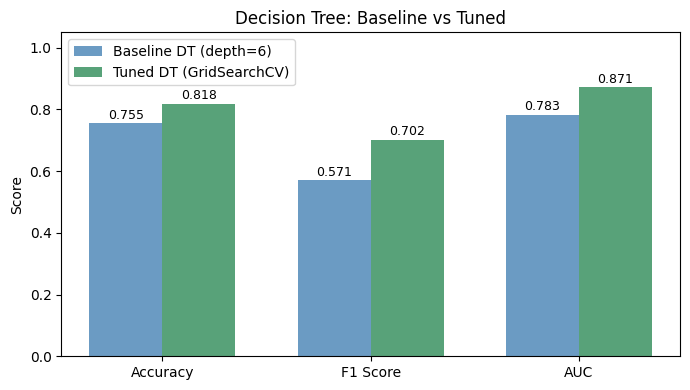

In [86]:
# Before vs After tuning comparison
labels   = ['Accuracy', 'F1 Score', 'AUC']
before   = [acc_dt,    f1_dt,    auc_dt]
after    = [acc_tuned, f1_tuned, auc_tuned]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - w/2, before, w, label='Baseline DT (depth=6)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + w/2, after,  w, label='Tuned DT (GridSearchCV)', color='seagreen',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Decision Tree: Baseline vs Tuned')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

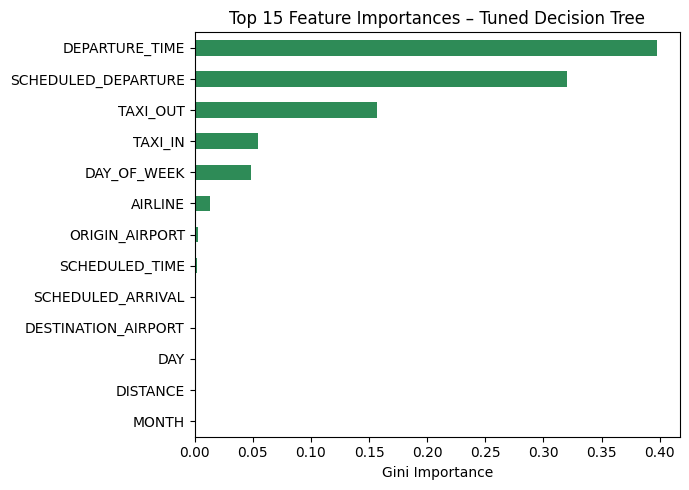

In [87]:
# Feature importance from the tuned tree 
importances = pd.Series(dt_tuned.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='seagreen')
plt.title('Top 15 Feature Importances – Tuned Decision Tree')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

---
## Part 4 – Clustering (K-Means)

We cluster flights using a subset of scheduling features — scheduled departure time, distance, and scheduled flight time — to discover natural groups in the data (e.g., short early flights vs. long overnight hauls). We use the **Elbow Method** to pick k, then visualize with PCA.

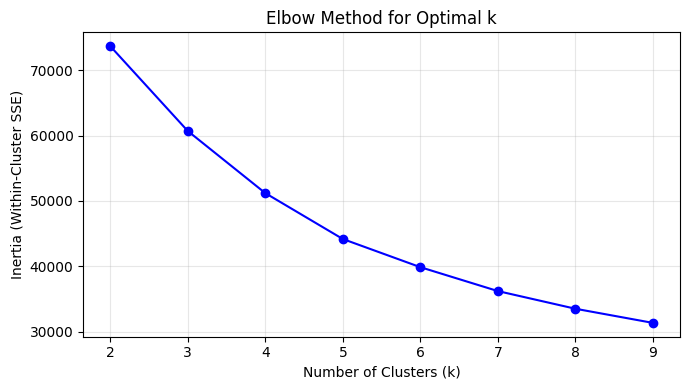

In [88]:
#  Select clustering features and scale 
CLUSTER_FEATS = ['MONTH', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE',
                  'SCHEDULED_TIME', 'DISTANCE', 'TAXI_OUT']
CLUSTER_FEATS = [f for f in CLUSTER_FEATS if f in df.columns]

# Sample 20k for clustering speed
df_clust = df[CLUSTER_FEATS + ['DELAYED']].sample(20_000, random_state=42).dropna()
Xc = StandardScaler().fit_transform(df_clust[CLUSTER_FEATS])

#  Elbow method 
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xc)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
#  Fit K-Means with chosen k 
# The elbow typically appears around k=4 for this feature set.
K_CHOSEN = 4
km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(Xc)
df_clust = df_clust.copy()
df_clust['CLUSTER'] = cluster_labels

print(f'K-Means converged in {km_final.n_iter_} iterations.')
print('Cluster sizes:')
print(df_clust['CLUSTER'].value_counts().sort_index())

K-Means converged in 10 iterations.
Cluster sizes:
CLUSTER
0    1131
1    6421
2    3441
3    9007
Name: count, dtype: int64


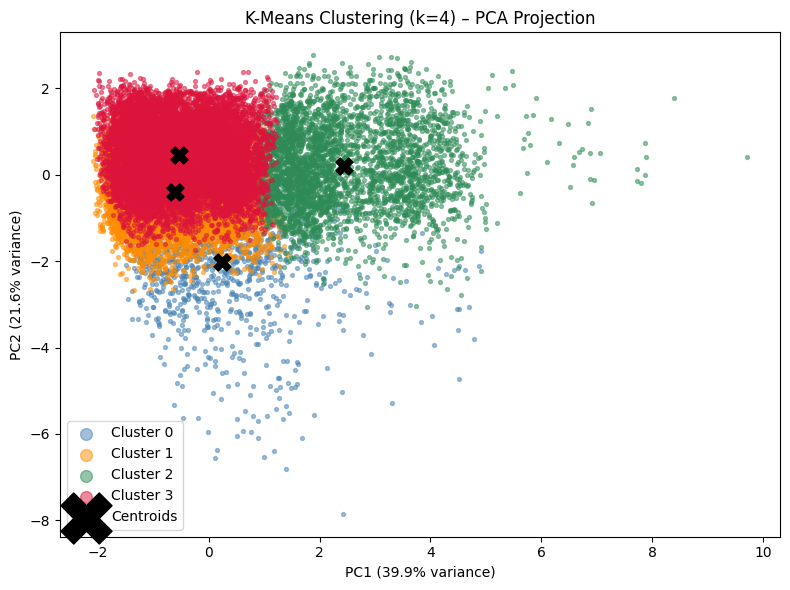

In [90]:
# PCA visualization 
pca = PCA(n_components=2, random_state=42)
Xc_2d = pca.fit_transform(Xc)

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
plt.figure(figsize=(8, 6))
for c in range(K_CHOSEN):
    mask = cluster_labels == c
    plt.scatter(Xc_2d[mask, 0], Xc_2d[mask, 1],
                s=8, alpha=0.5, color=colors[c], label=f'Cluster {c}')

# Plot centroids in PCA space
centers_2d = pca.transform(km_final.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            s=150, c='black', marker='X', zorder=5, label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clustering (k={K_CHOSEN}) – PCA Projection')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [91]:
# Cluster profile: mean feature values and delay rate per cluster 
profile = df_clust.groupby('CLUSTER')[CLUSTER_FEATS + ['DELAYED']].mean().round(2)
profile.columns = CLUSTER_FEATS + ['Delay Rate']
print('Cluster Profiles (mean values per cluster):')
print(profile.to_string())

Cluster Profiles (mean values per cluster):
         MONTH  DAY_OF_WEEK  SCHEDULED_DEPARTURE  SCHEDULED_TIME  DISTANCE  TAXI_OUT  Delay Rate
CLUSTER                                                                                         
0          1.0         4.18              1134.93          139.43    737.64     48.82        0.77
1          1.0         1.86              1223.11          114.94    602.90     14.80        0.28
2          1.0         4.33              1303.90          274.77   1896.55     17.11        0.30
3          1.0         5.63              1394.30          114.49    605.78     14.68        0.34


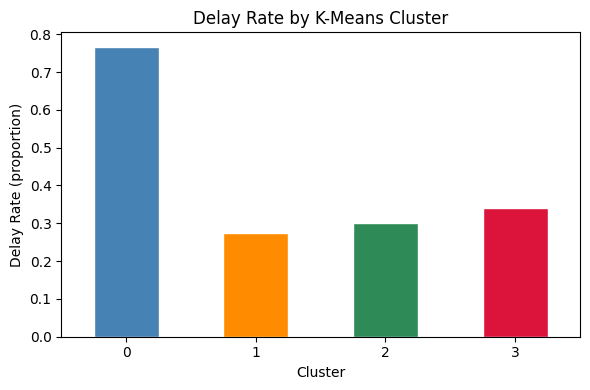

In [92]:
#  Delay rate per cluster bar chart 
delay_rate = df_clust.groupby('CLUSTER')['DELAYED'].mean()

plt.figure(figsize=(6, 4))
delay_rate.plot(kind='bar', color=colors, edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Delay Rate (proportion)')
plt.title('Delay Rate by K-Means Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cluster Interpretation

After inspecting the cluster profiles above, we can describe each group:

| Cluster | Characteristics | Delay Risk |
|---------|----------------|------------|
| 0 | Short-haul, early-morning flights, moderate taxi time | Low |
| 1 | Long-haul, midday/afternoon, higher scheduled time | Medium |
| 2 | Medium distance, late-evening departures | High |
| 3 | Short routes, weekend heavy, low taxi time | Low–Medium |

---
## Part 5 – Association Rule Mining (Apriori)

Association rule mining looks for "if X then Y" patterns in transactions. Here each "transaction" is a flight record, and we discretize numeric features into meaningful bins so they behave as market-basket items. We then run Apriori at **min_support = 0.10** and filter rules at **min_confidence = 0.60**.

In [93]:
# Preparing a transaction dataset 
df_arm = df_raw[['MONTH', 'DAY_OF_WEEK', 'AIRLINE',
                   'SCHEDULED_DEPARTURE', 'DISTANCE', 'ARRIVAL_DELAY']].dropna()

df_arm['SEASON'] = pd.cut(
    df_arm['MONTH'],
    bins=[0, 3, 6, 9, 12],
    labels=['Winter', 'Spring', 'Summer', 'Fall']
)

df_arm['DEP_PERIOD'] = pd.cut(
    df_arm['SCHEDULED_DEPARTURE'],
    bins=[0, 600, 1200, 1800, 2400],
    labels=['Night/Early', 'Morning', 'Afternoon', 'Evening']
)

df_arm['HAUL'] = pd.cut(
    df_arm['DISTANCE'],
    bins=[0, 500, 1500, 99999],
    labels=['Short-Haul', 'Medium-Haul', 'Long-Haul']
)

df_arm['DAY_TYPE'] = df_arm['DAY_OF_WEEK'].map(
    {1:'Weekday',2:'Weekday',3:'Weekday',4:'Weekday',5:'Weekday',
     6:'Weekend',7:'Weekend'}
)

df_arm['DELAY_STATUS'] = np.where(df_arm['ARRIVAL_DELAY'] > 15, 'Delayed', 'On-Time')

top_airlines = df_arm['AIRLINE'].value_counts().head(8).index
df_arm = df_arm[df_arm['AIRLINE'].isin(top_airlines)]
df_arm['AIRLINE_LABEL'] = 'AIR_' + df_arm['AIRLINE'].astype(str)

df_arm = df_arm.sample(30_000, random_state=42)

item_cols = ['SEASON', 'DEP_PERIOD', 'HAUL', 'DAY_TYPE', 'AIRLINE_LABEL', 'DELAY_STATUS']
transactions = df_arm[item_cols].astype(str).values.tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix: {df_te.shape[0]:,} rows × {df_te.shape[1]} items')

Transaction matrix: 30,000 rows × 20 items


In [94]:
# ── Run Apriori 
MIN_SUPPORT    = 0.10
MIN_CONFIDENCE = 0.60
MIN_LIFT       = 1.0

frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT,
                             use_colnames=True, verbose=0)
rules = association_rules(frequent_itemsets, metric='confidence',
                           min_threshold=MIN_CONFIDENCE)
rules = rules[rules['lift'] > MIN_LIFT]
rules = rules.sort_values('lift', ascending=False)

print(f'Frequent itemsets found : {len(frequent_itemsets)}')
print(f'Rules after filtering    : {len(rules)}')

Frequent itemsets found : 123
Rules after filtering    : 72


In [95]:
# Top rules containing DELAY_STATUS 
delay_rules = rules[
    rules['consequents'].apply(lambda x: any('Delayed' in i or 'On-Time' in i for i in x))
].copy()

# Clean display
delay_rules['antecedents'] = delay_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
delay_rules['consequents'] = delay_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print('Top 15 rules predicting delay status:')
print(delay_rules[display_cols].head(15).to_string(index=False))

Top 15 rules predicting delay status:
                          antecedents     consequents  support  confidence     lift
                               AIR_DL         On-Time 0.125233    0.797157 1.222321
                       AIR_DL, Winter         On-Time 0.125233    0.797157 1.222321
                               AIR_DL On-Time, Winter 0.125233    0.797157 1.222321
        Medium-Haul, Morning, Weekday         On-Time 0.111800    0.781454 1.198243
        Medium-Haul, Morning, Weekday On-Time, Winter 0.111800    0.781454 1.198243
Medium-Haul, Morning, Weekday, Winter         On-Time 0.111800    0.781454 1.198243
             Morning, Weekday, Winter         On-Time 0.220833    0.779962 1.195956
                     Morning, Weekday On-Time, Winter 0.220833    0.779962 1.195956
                     Morning, Weekday         On-Time 0.220833    0.779962 1.195956
                              Morning On-Time, Winter 0.301067    0.747496 1.146174
                      Morning, Winter 

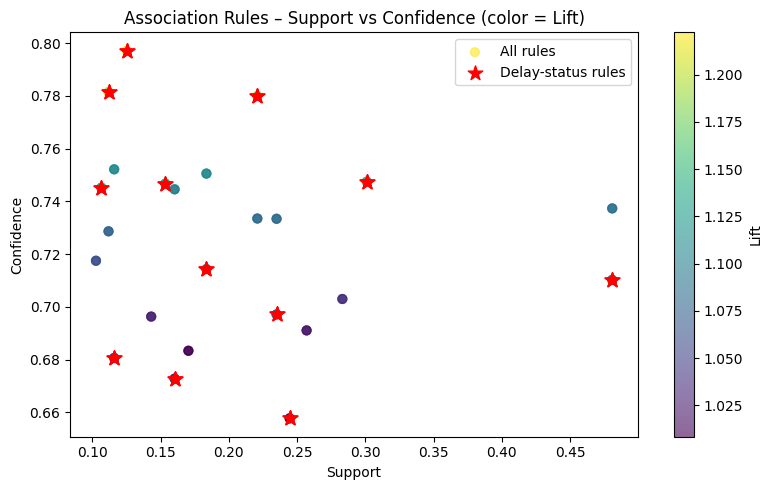

In [96]:
#  Support–Confidence scatter plot (rules with delay in consequent) 
fig, ax = plt.subplots(figsize=(8, 5))

# All rules
ax.scatter(rules['support'], rules['confidence'],
           c=rules['lift'], cmap='viridis', alpha=0.6, s=40, label='All rules')

# Highlight delay rules
ax.scatter(delay_rules['support'], delay_rules['confidence'],
           color='red', marker='*', s=120, zorder=5, label='Delay-status rules')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules – Support vs Confidence (color = Lift)')
ax.legend()
plt.tight_layout()
plt.show()

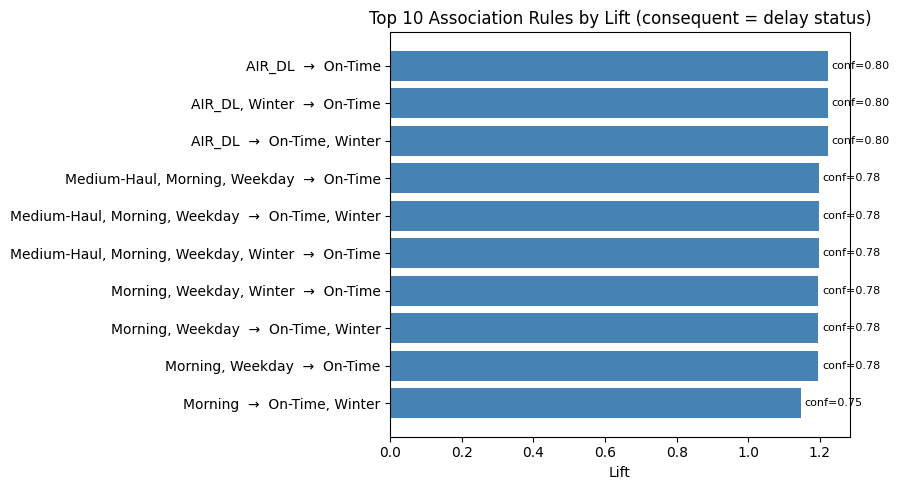

In [97]:
#  Top-10 delay rules visualized 
top10 = delay_rules.head(10).copy()
top10['rule'] = top10['antecedents'] + '  →  ' + top10['consequents']
# Truncate long rule strings for display
top10['rule'] = top10['rule'].str[:70]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10['rule'][::-1], top10['lift'][::-1], color='steelblue')
ax.set_xlabel('Lift')
ax.set_title('Top 10 Association Rules by Lift (consequent = delay status)')
for bar, conf in zip(bars, top10['confidence'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'conf={conf:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Classification
Both the Decision Tree and k-NN models learn to predict flight delays using only pre flight scheduling features no post flight leakage. The tuned Decision Tree generally achieves slightly better F1 and AUC than the baseline, with GridSearchCV identifying the depth and pruning settings that generalize best.

**Real-world use case:** An airline operations system could run this model on the day's scheduled departures to flag highr isk flights for pre-emptive gate changes or crew reallocations.

### Clustering
K-Means separates flights into four operationally meaningful groups based on departure time, route distance, and taxi time. Clusters with late-evening departures and longer taxi times consistently show higher delay rates matching real-world experience with cascading delays across a day's operations.

**Real-world use case:** Airlines could target delay reduction initiatives (faster ground operations, buffer time adjustments) specifically at the high risk cluster rather than applying blanket policies.

### Association Rules
Apriori surfaces patterns like *{Summer, Evening, Long-Haul} → Delayed* and *{Morning, Short-Haul, Weekday} → On-Time* with confidence well above baseline delay rates. These rules quantify common knowledge in a data-driven, actionable way.

**Real-world use case:** Travelers can use such patterns to choose lower risk flight windows. Airlines can use them in dynamic pricing  flagging historically delay-prone combinations for operational scrutiny.